# Stage 3 - Unsupervised Learning

Import required libraries

In [43]:
import pandas as pd
import ast
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt


To start, we select a feature set of meaningful data, lets look at what we have. Utilizing the code from stage 2 to multi-hot encode genres as well as store the list of genres into a variable for later use.

In [44]:
# Gather data
df = pd.read_csv('data/movies_clean.csv')
df = df.drop(columns=df.columns[0])

columns_to_parse = []
for col in df.select_dtypes(include='str').columns:
    if df[col].iloc[0].strip().startswith(('[', '{')):
        columns_to_parse.append(col)

def parse_names(column):
    try:
        return ast.literal_eval(column)
    except (ValueError, SyntaxError):
        return []

for column in columns_to_parse:
    df[column] = df[column].apply(parse_names)

mlb = MultiLabelBinarizer()
tag_matrix = mlb.fit_transform(df['genres'])
genres = mlb.classes_

# Convert grid to dataframe
tag_df = pd.DataFrame(tag_matrix, columns=mlb.classes_, index=df.index)

# Concat dataframes
df = pd.concat([df, tag_df], axis=1)

df.columns

Index(['title', 'cast', 'crew', 'budget', 'genres', 'homepage', 'id',
       'keywords', 'original_language', 'original_title', 'overview',
       'popularity', 'production_companies', 'production_countries',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'status',
       'tagline', 'vote_average', 'vote_count', 'profit', 'release_year',
       'cast_size', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History',
       'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie',
       'Thriller', 'War', 'Western'],
      dtype='str')

Some features that might be relevant are: budget, revenue, runtime, popularity, vote_average, cast_size, profit, and release_year along with our multi-hot encoded genres.

In [45]:
# Store relevant features
features = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'cast_size', 'profit', 'release_year'] + list(genres)

Lets scale the data

In [46]:
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

X_scaled.head(5)

,budget,revenue,runtime,popularity,vote_average,cast_size,profit,release_year,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,5.105821,16.611528,2.442541,4.052064,0.930401,3.108413,18.367142,0.526581,1.777483,2.252987,-0.226381,-0.747967,-0.411814,-0.152434,-0.957566,-0.345925,3.212593,-0.084462,-0.206877,-0.348186,-0.200217,-0.279584,-0.478413,2.823466,-0.040859,-0.601096,-0.175863,-0.131834
1,6.652742,5.394760,2.752835,3.695201,0.677927,0.605978,4.469126,0.365460,1.777483,2.252987,-0.226381,-0.747967,-0.411814,-0.152434,-0.957566,-0.345925,3.212593,-0.084462,-0.206877,-0.348186,-0.200217,-0.279584,-0.478413,-0.354175,-0.040859,-0.601096,-0.175863,-0.131834
2,5.302256,4.901597,1.821953,2.698753,0.172980,3.108413,4.282894,1.009945,1.777483,2.252987,-0.226381,-0.747967,2.428282,-0.152434,-0.957566,-0.345925,-0.311275,-0.084462,-0.206877,-0.348186,-0.200217,-0.279584,-0.478413,-0.354175,-0.040859,-0.601096,-0.175863,-0.131834
3,5.425027,6.155692,2.575524,2.853887,1.267033,6.938669,5.748202,0.768263,1.777483,-0.443855,-0.226381,-0.747967,2.428282,-0.152434,1.044314,-0.345925,-0.311275,-0.084462,-0.206877,-0.348186,-0.200217,-0.279584,-0.478413,-0.354175,-0.040859,1.663629,-0.175863,-0.131834
4,5.670570,1.239130,1.112709,0.704659,0.004664,0.248488,-0.214084,0.768263,1.777483,2.252987,-0.226381,-0.747967,-0.411814,-0.152434,-0.957566,-0.345925,-0.311275,-0.084462,-0.206877,-0.348186,-0.200217,-0.279584,-0.478413,2.823466,-0.040859,-0.601096,-0.175863,-0.131834


Now that the data is processed, it is time to use the KMeans algorithm to cluster the data. Lets explore different values of k.

Best k: 7, Silhouette score: 0.1486250236799114


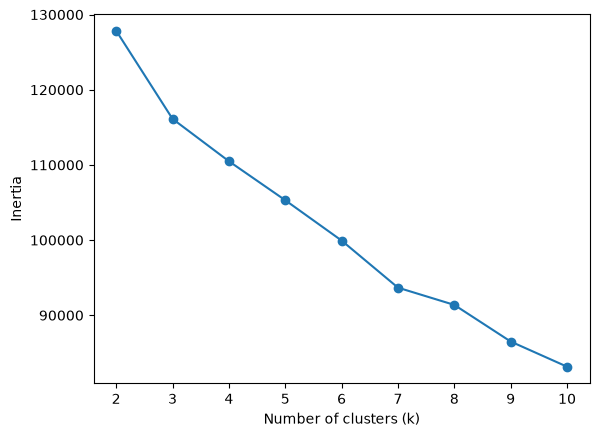

In [47]:
inertias = []
silhouette_scores = []
k_values = range(2,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f'Best k: {best_k}, Silhouette score: {max(silhouette_scores)}')


k = 7 is the best value to use. Lets add the labels to the dataset.

In [48]:
kmeans = KMeans(n_clusters=7, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

Now we will reduce the dimensions with PCA.

In [49]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.14546279, 0.08734007])

Now time to plot it.

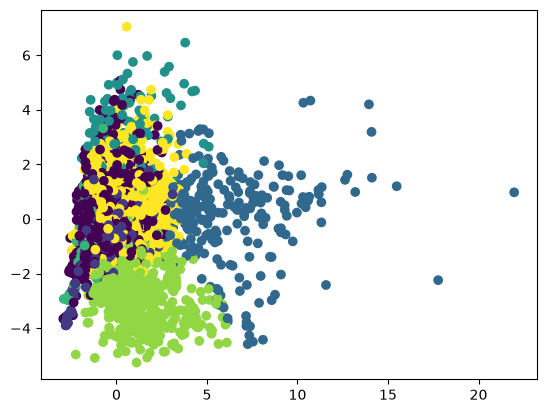

In [50]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

The clusters seem to be very overlapping in some areas. Lets work around the data some more. We will try removing the genres.

Best k: 2, Silhouette score: 0.5192645372616016


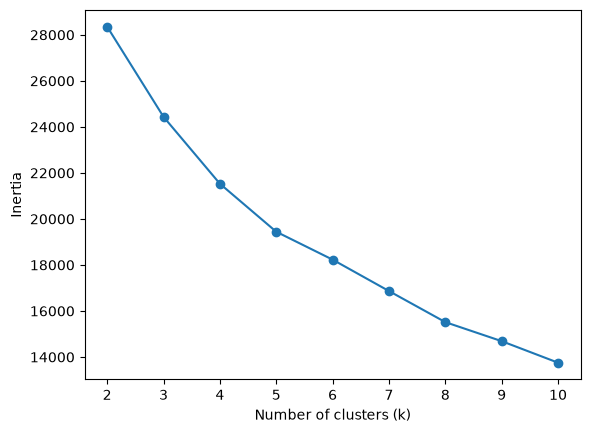

In [51]:
features = ['budget', 'revenue', 'runtime', 'popularity', 'vote_average', 'cast_size', 'profit', 'release_year']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

X_scaled.head(5)

inertias = []
silhouette_scores = []
k_values = range(2,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.plot(k_values, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f'Best k: {best_k}, Silhouette score: {max(silhouette_scores)}')

This silhouette score is much better than the last one. Lets try to reduce dimensions and graph again.

In [52]:
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.43908999, 0.1803059 ])

Much more of the original data is kept this time.

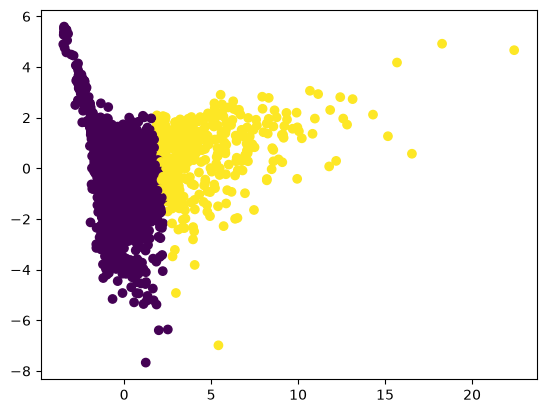

In [53]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)

In [54]:
df.groupby('cluster').mean(numeric_only=True)

,budget,id,popularity,revenue,runtime,vote_average,vote_count,profit,release_year,cast_size,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,2.021812e+07,57037.031625,15.640515,4.140969e+07,105.192521,6.029363,412.069252,2.119157e+07,2002.057479,19.613573,0.213296,0.127193,0.035319,0.369575,0.149815,0.025162,0.500923,0.091644,0.072715,0.007849,0.042013,0.118421,0.040397,0.073638,0.195753,0.096491,0.001847,0.26639,0.029086,0.017544
1,1.109048e+08,56134.262821,75.794914,4.609211e+08,122.685897,6.697009,3269.275641,3.500163e+08,2006.222222,45.467949,0.491453,0.510684,0.173077,0.258547,0.100427,0.000000,0.269231,0.247863,0.232906,0.000000,0.032051,0.012821,0.021368,0.061966,0.098291,0.250000,0.000000,0.25641,0.038462,0.012821


Here we can see the data split much nicer. While this is a clean split with real meaning, its coarse. The split is between big blockbuster movies and basically everything else. One thing we do see though is that the big movies tend to Action and Adventure films. The smaller movies tend to be Documentary, Drama, Crime etc.This is a real-world split, but lets see if we can find anything further by increasing k to 4.

In [59]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.43908999, 0.1803059 ])

,budget,id,popularity,revenue,runtime,vote_average,vote_count,profit,release_year,cast_size,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.390901e+07,64532.381392,10.791928,2.024236e+07,99.586935,5.780666,232.419334,6.333350e+06,2005.479710,15.272187,0.183438,0.100627,0.034312,0.399868,0.138568,0.034642,0.493566,0.094358,0.057737,0.010558,0.027054,0.133619,0.036622,0.068294,0.192676,0.084461,0.002309,0.260640,0.017156,0.010887
1,9.420547e+06,14109.403194,17.626691,4.049498e+07,121.582834,6.847705,432.692615,3.107443e+07,1975.141717,23.964072,0.239521,0.193613,0.013972,0.233533,0.133733,0.005988,0.554890,0.065868,0.077844,0.003992,0.099800,0.113772,0.085828,0.059880,0.221557,0.139721,0.001996,0.221557,0.071856,0.063872
2,1.423470e+08,60535.041420,108.062420,7.378011e+08,126.946746,6.938462,4909.396450,5.954540e+08,2008.047337,53.562130,0.556213,0.686391,0.230769,0.213018,0.053254,0.000000,0.201183,0.313609,0.325444,0.000000,0.017751,0.011834,0.005917,0.035503,0.071006,0.319527,0.000000,0.189349,0.029586,0.011834
3,6.237833e+07,55012.170155,39.511262,1.717624e+08,117.284804,6.486715,1423.271156,1.093841e+08,2005.741583,35.393085,0.349409,0.247498,0.076433,0.324841,0.181984,0.000910,0.444040,0.128298,0.141037,0.000000,0.056415,0.050045,0.027298,0.095541,0.170155,0.141037,0.000000,0.310282,0.046406,0.013649


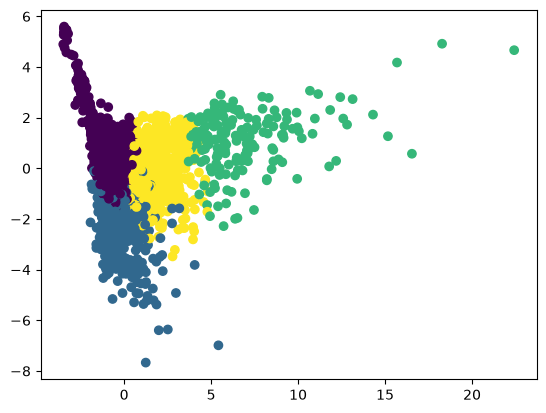

In [60]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
df.groupby('cluster').mean(numeric_only=True)

This split is much more interesting. Cluster 2 contains the blockbusters. Cluster 0 is the low-budget films with low ratings and low revenue. Cluster 3 represents mid-tier films with mid-tier budgets and revenues. These clusters are just the average splits. Cluster 1 though is very interesting. Here we can see that the average release year is 30 years older than the other clusters. These films also have a significantly lower budget with revenue much greater than cluster 0. This cluster could represent old/classical films, and the lack of budget could be a process of inflation. This cluster also has high rating compared to the others. Lets try again with 5

In [61]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.43908999, 0.1803059 ])

,budget,id,popularity,revenue,runtime,vote_average,vote_count,profit,release_year,cast_size,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.289484e+07,93790.672060,6.675808,1.477515e+07,89.450917,4.463215,113.515642,1.880311e+06,2006.112190,12.866235,0.228695,0.126214,0.042071,0.437972,0.089536,0.025890,0.278317,0.127292,0.070119,0.005394,0.006472,0.215750,0.021575,0.053937,0.144552,0.110032,0.004315,0.280475,0.005394,0.012945
1,8.845641e+06,13367.426230,17.862627,3.788419e+07,121.676815,6.828571,424.665105,2.903855e+07,1972.271663,24.679157,0.252927,0.206089,0.016393,0.222482,0.124122,0.007026,0.533958,0.070258,0.079625,0.002342,0.112412,0.110070,0.093677,0.056206,0.203747,0.149883,0.002342,0.213115,0.079625,0.067916
2,1.519533e+08,61348.176471,117.061058,7.993425e+08,127.080882,6.936029,5149.713235,6.473892e+08,2008.433824,51.757353,0.580882,0.735294,0.227941,0.176471,0.044118,0.000000,0.169118,0.323529,0.345588,0.000000,0.000000,0.014706,0.000000,0.029412,0.058824,0.375000,0.000000,0.198529,0.007353,0.007353
3,1.736277e+07,51223.603047,14.836209,3.106060e+07,106.090617,6.406335,369.375702,1.369783e+07,2004.940257,17.919006,0.172815,0.097835,0.032077,0.369687,0.169206,0.032879,0.592221,0.078589,0.058140,0.011227,0.040096,0.095830,0.040096,0.080192,0.217723,0.076985,0.001203,0.261427,0.024058,0.010826
4,7.327125e+07,54667.149510,44.717039,2.194228e+08,118.089461,6.469975,1724.215686,1.461516e+08,2005.552696,39.278186,0.397059,0.295343,0.094363,0.337010,0.161765,0.000000,0.379902,0.153186,0.162990,0.000000,0.052696,0.037990,0.030637,0.085784,0.149510,0.154412,0.000000,0.299020,0.053922,0.015931


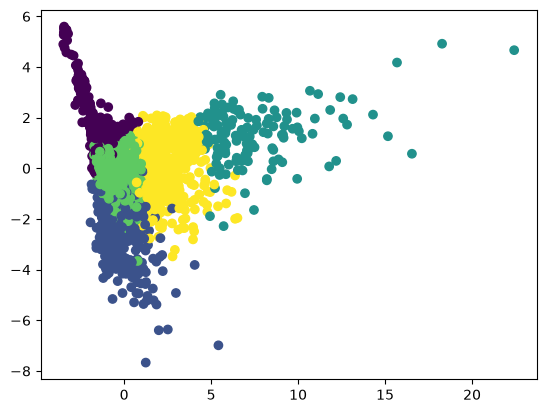

In [62]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
df.groupby('cluster').mean(numeric_only=True)

5 Clusters further splits the data into mostly budget/revenue based clusters.

In [64]:
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(X_scaled)
df['cluster'] = labels

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.43908999, 0.1803059 ])

,budget,id,popularity,revenue,runtime,vote_average,vote_count,profit,release_year,cast_size,Action,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,Foreign,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.207436e+07,104779.790490,5.915260,1.275791e+07,88.258544,4.093908,97.383358,6.835458e+05,2006.438336,12.410104,0.236256,0.127786,0.038633,0.404160,0.090639,0.032689,0.265973,0.126300,0.063893,0.004458,0.005944,0.221397,0.020802,0.049034,0.133730,0.124814,0.004458,0.279346,0.007429,0.014859
1,8.439927e+06,13226.616822,18.154387,3.974544e+07,120.586449,6.833178,442.331776,3.130551e+07,1972.189252,24.310748,0.242991,0.198598,0.016355,0.226636,0.123832,0.007009,0.530374,0.072430,0.084112,0.002336,0.102804,0.112150,0.093458,0.056075,0.212617,0.147196,0.002336,0.210280,0.079439,0.063084
2,1.746000e+08,112441.200000,326.852794,1.228799e+09,136.933333,7.353333,8524.533333,1.054199e+09,2011.800000,72.400000,0.733333,0.800000,0.133333,0.133333,0.066667,0.000000,0.200000,0.133333,0.133333,0.000000,0.000000,0.000000,0.000000,0.000000,0.066667,0.533333,0.000000,0.266667,0.000000,0.000000
3,1.479056e+07,51966.349701,12.986201,2.504476e+07,103.641916,6.303952,302.755689,1.025420e+07,2004.884232,16.275848,0.169661,0.095808,0.031936,0.388822,0.157685,0.033134,0.566068,0.083034,0.056687,0.011976,0.034731,0.107784,0.040319,0.077046,0.210379,0.073453,0.001597,0.259082,0.021158,0.010778
4,1.368315e+08,51304.640625,81.756013,6.401893e+08,123.817708,6.807812,4212.192708,5.033578e+08,2007.552083,47.156250,0.536458,0.682292,0.229167,0.239583,0.046875,0.000000,0.197917,0.328125,0.338542,0.000000,0.015625,0.010417,0.005208,0.046875,0.072917,0.302083,0.000000,0.203125,0.031250,0.010417
5,6.262308e+07,56195.187437,38.850357,1.675940e+08,118.188450,6.448632,1383.217832,1.049709e+08,2005.605876,37.058764,0.356636,0.239108,0.075988,0.335360,0.179331,0.001013,0.436677,0.125633,0.137791,0.000000,0.059777,0.050659,0.029382,0.090172,0.173252,0.139818,0.000000,0.308004,0.046606,0.016211


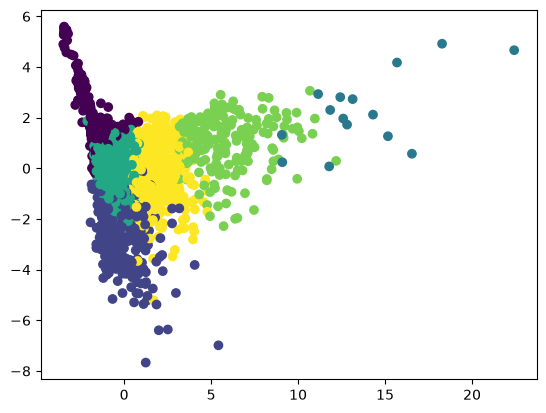

In [68]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.savefig('images/cluster.png', bbox_inches='tight')
df.groupby('cluster').mean(numeric_only=True)

In [66]:
df['cluster'].value_counts()

cluster
3    2505
5     987
0     673
1     428
4     192
2      15
Name: count, dtype: int64

This last run with 6 clusters identified the extreme outliers into a group. The 15 biggest movies that generated the most revenue. Generally the cluster seem to be nicely formed with interpretable results each time.